In [14]:
#conda activate pathformer
import deepmimo as dm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
scenario = 'asu_campus_3p5'
# Download a Scenario
dm.download(scenario)

# Load to memory
dataset = dm.load(scenario)

def plot_multipath_on_scene(user_idx, title=None):
    ax = dataset.scene.plot(title=False, proj_3D=False)
    dataset.plot_rays(user_idx, ax=ax, proj_3D=False)
    ax.set_title(title or f"User {user_idx}: multipath over environment")
    plt.tight_layout()
    return ax


Scenario "asu_campus_3p5" already exists in /home/blessedg/Pathformer/deepmimo_scenarios
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 131931)


<Axes3D: title={'center': 'Buildings: 35, Terrain: 1'}, xlabel='X (m)', ylabel='Y (m)', zlabel='Z (m)'>

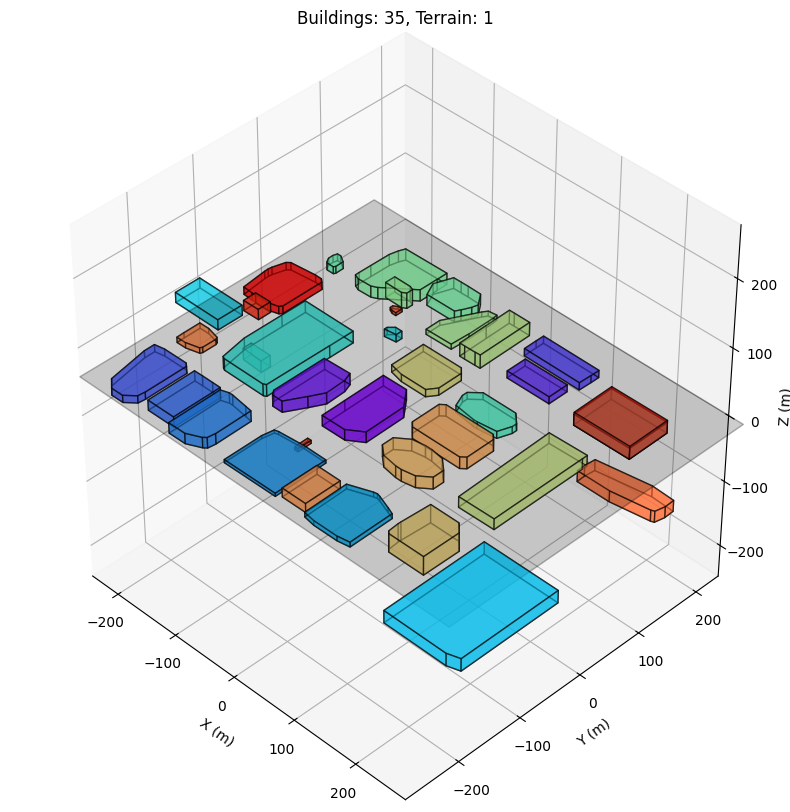

In [2]:
dataset.scene.plot()

<Axes: title={'center': 'User 21735: multipath over environment'}, xlabel='x (m)', ylabel='y (m)'>

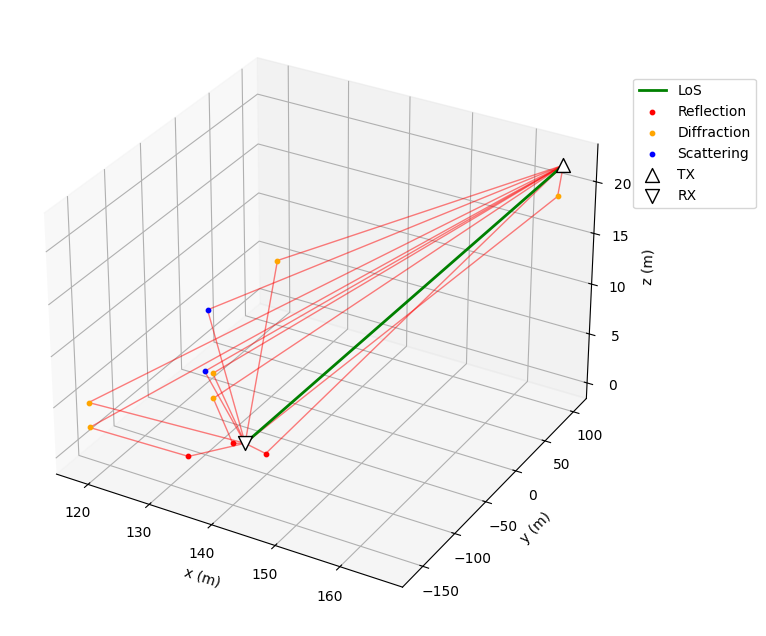

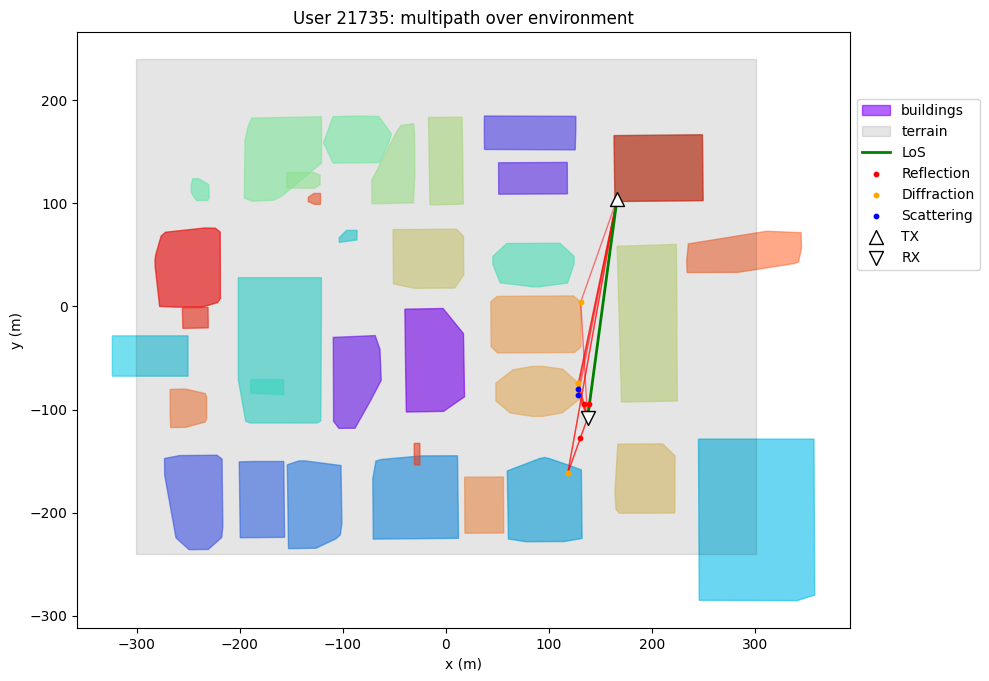

In [3]:
# Plot ray paths for a user in line of sight
los_user = np.where(dataset.los == 1)[0][2500]
dataset.plot_rays(los_user)
plot_multipath_on_scene(los_user)

<Axes: title={'center': 'User 3660: multipath over environment'}, xlabel='x (m)', ylabel='y (m)'>

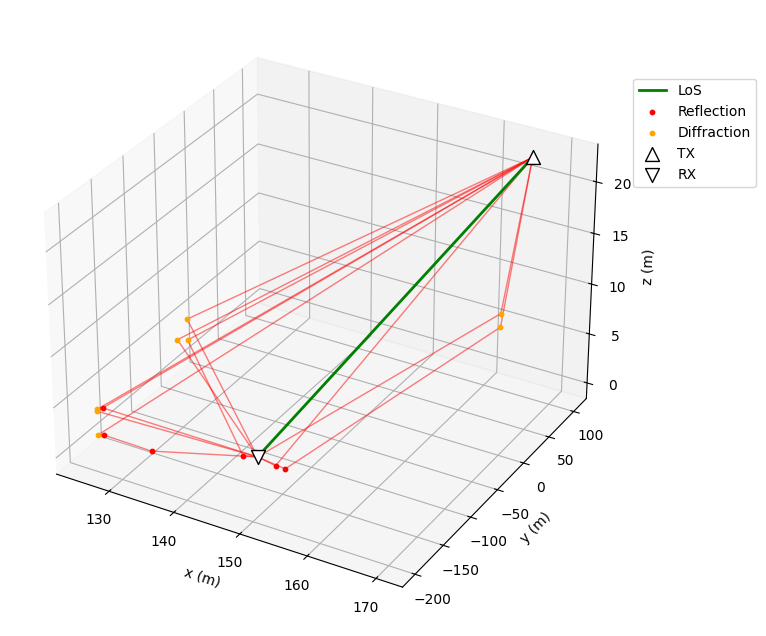

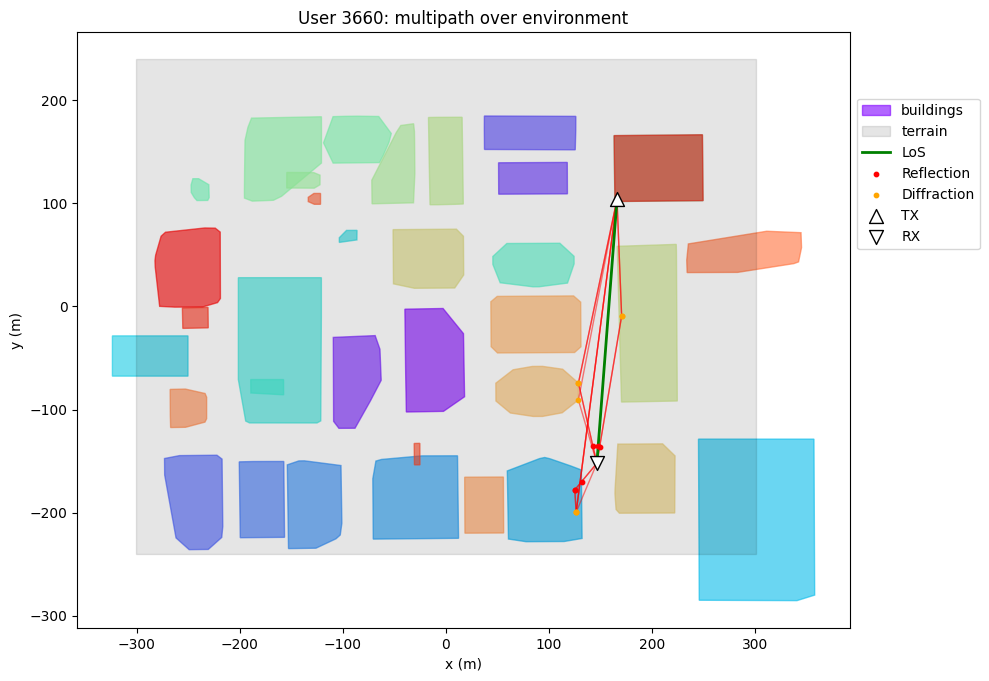

In [4]:
# Plot ray paths for a user in line of sight
los_user = np.where(dataset.los == 1)[0][390]
dataset.plot_rays(los_user)
plot_multipath_on_scene(los_user)

(<Axes: xlabel='x (m)', ylabel='y (m)'>,
 <matplotlib.colorbar.Colorbar at 0x15543ba43fa0>)

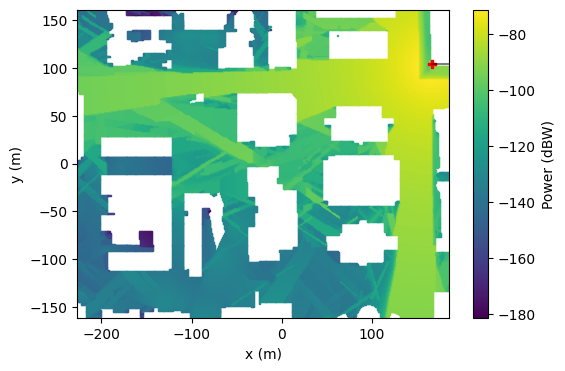

In [5]:
# Plot power coverage map (power is [n_ue, n_paths])
dataset.power.plot() # selects first path by default

In [6]:
dataset.info()


Fundamental Matrices:
power: Tap power. Received power in dBW for each path, assuming 0 dBW transmitted power. 
10*log10(|a|²), where a is the complex channel amplitude
	[num_rx, num_paths]
phase: Tap phase. Phase of received signal for each path in degrees. 
∠a (angle of a), where a is the complex channel amplitude
	[num_rx, num_paths]
delay: Tap delay. Propagation delay for each path in seconds
	[num_rx, num_paths]
aoa_az: Angle of arrival (azimuth) for each path in degrees
	[num_rx, num_paths]
aoa_el: Angle of arrival (elevation) for each path in degrees
	[num_rx, num_paths]
aod_az: Angle of departure (azimuth) for each path in degrees
	[num_rx, num_paths]
aod_el: Angle of departure (elevation) for each path in degrees
	[num_rx, num_paths]
inter: Type of interactions along each path
	Codes: 0: LOS, 1: Reflection, 2: Diffraction, 3: Scattering, 4: Transmission
	Code meaning: 121 -> Tx-R-D-R-Rx
	[num_rx, num_paths]
inter_pos: 3D coordinates in meters of each interaction point along p

In [7]:
dm.info()


Fundamental Matrices:
power: Tap power. Received power in dBW for each path, assuming 0 dBW transmitted power. 
10*log10(|a|²), where a is the complex channel amplitude
	[num_rx, num_paths]
phase: Tap phase. Phase of received signal for each path in degrees. 
∠a (angle of a), where a is the complex channel amplitude
	[num_rx, num_paths]
delay: Tap delay. Propagation delay for each path in seconds
	[num_rx, num_paths]
aoa_az: Angle of arrival (azimuth) for each path in degrees
	[num_rx, num_paths]
aoa_el: Angle of arrival (elevation) for each path in degrees
	[num_rx, num_paths]
aod_az: Angle of departure (azimuth) for each path in degrees
	[num_rx, num_paths]
aod_el: Angle of departure (elevation) for each path in degrees
	[num_rx, num_paths]
inter: Type of interactions along each path
	Codes: 0: LOS, 1: Reflection, 2: Diffraction, 3: Scattering, 4: Transmission
	Code meaning: 121 -> Tx-R-D-R-Rx
	[num_rx, num_paths]
inter_pos: 3D coordinates in meters of each interaction point along p

In [21]:
all_scenarios = [
    'city_47_chicago_3p5',
    'city_23_beijing_3p5',
    'city_91_xiangyang_3p5',
    'city_17_seattle_3p5_s',
    'city_12_fortworth_3p5',
    'city_92_sãopaulo_3p5',
    'city_35_san_francisco_3p5',
    'city_10_florida_villa_7gp_1758095156175',
    'city_19_oklahoma_3p5_s',
    'city_74_chiyoda_3p5',
]
output_csv = 'scenario_dataset_description.csv'

In [22]:
from pathlib import Path

import pandas as pd


def _safe_mean(values):
    values = np.asarray(values, dtype=float).reshape(-1)
    values = values[np.isfinite(values)]
    return float(values.mean()) if values.size else np.nan


def _safe_max(values):
    values = np.asarray(values, dtype=float).reshape(-1)
    values = values[np.isfinite(values)]
    return float(values.max()) if values.size else np.nan


def _as_pos_2d(values):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        return values.reshape(1, -1)
    return values.reshape(-1, values.shape[-1])


def _scenario_summary_row(scenario_name):
    loaded = dm.load(scenario_name)
    datasets = loaded if isinstance(loaded, list) else [loaded]

    scene = datasets[0].scene
    scene_bbox = scene.bounding_box
    label_counts = scene.count_objects_by_label()
    building_objects = list(scene.get_objects(label='buildings'))
    building_heights = np.array([obj.height for obj in building_objects], dtype=float) if building_objects else np.array([])

    all_rx_pos = np.vstack([_as_pos_2d(ds.rx_pos) for ds in datasets])
    all_tx_pos = np.vstack([_as_pos_2d(ds.tx_pos) for ds in datasets])
    all_num_paths = np.concatenate([np.asarray(ds.num_paths).reshape(-1) for ds in datasets])
    all_los = np.concatenate([np.asarray(ds.los).reshape(-1) for ds in datasets])
    all_geom_distance = np.concatenate([
        np.linalg.norm(_as_pos_2d(ds.rx_pos) - _as_pos_2d(ds.tx_pos)[0], axis=1)
        for ds in datasets
    ])
    all_pathloss = np.concatenate([np.asarray(ds.pathloss).reshape(-1) for ds in datasets])

    active_mask = all_num_paths > 0
    rx_min = all_rx_pos.min(axis=0)
    rx_max = all_rx_pos.max(axis=0)
    rx_width = float(rx_max[0] - rx_min[0])
    rx_length = float(rx_max[1] - rx_min[1])
    rx_height = float(rx_max[2] - rx_min[2])
    rx_area = float(rx_width * rx_length)
    scene_area = float(scene_bbox.width * scene_bbox.length)
    scene_volume = float(scene_bbox.width * scene_bbox.length * scene_bbox.height)
    active_users = int(active_mask.sum())

    return {
        'scenario': scenario_name,
        'num_tx_views': int(len(datasets)),
        'num_unique_tx_positions': int(np.unique(np.round(all_tx_pos, decimals=3), axis=0).shape[0]),
        'num_rx_total': int(all_rx_pos.shape[0]),
        'num_active_users': active_users,
        'active_user_ratio': float(active_users / all_rx_pos.shape[0]) if all_rx_pos.shape[0] else np.nan,
        'num_los_users': int(np.sum(all_los == 1)),
        'los_user_ratio': float(np.mean(all_los == 1)) if all_los.size else np.nan,
        'num_nlos_users': int(np.sum(all_los == 0)),
        'nlos_user_ratio': float(np.mean(all_los == 0)) if all_los.size else np.nan,
        'num_no_path_users': int(np.sum(all_los == -1)),
        'mean_num_paths_per_user': _safe_mean(all_num_paths),
        'mean_num_paths_active_user': _safe_mean(all_num_paths[active_mask]),
        'max_num_paths_user': _safe_max(all_num_paths),
        'mean_tx_rx_distance_m': _safe_mean(all_geom_distance),
        'mean_pathloss_db': _safe_mean(all_pathloss),
        'scene_num_objects': int(len(scene.objects)),
        'num_buildings': int(label_counts.get('buildings', 0)),
        'num_terrain': int(label_counts.get('terrain', 0)),
        'num_vegetation': int(label_counts.get('vegetation', 0)),
        'num_floorplans': int(label_counts.get('floorplans', 0)),
        'num_other_objects': int(label_counts.get('objects', 0)),
        'scene_width_m': float(scene_bbox.width),
        'scene_length_m': float(scene_bbox.length),
        'scene_height_m': float(scene_bbox.height),
        'scene_area_m2': scene_area,
        'scene_volume_m3': scene_volume,
        'building_density_per_km2': float(label_counts.get('buildings', 0) / scene_area * 1e6) if scene_area > 0 else np.nan,
        'mean_building_height_m': _safe_mean(building_heights),
        'max_building_height_m': _safe_max(building_heights),
        'tx_height_mean_m': _safe_mean(all_tx_pos[:, 2]),
        'rx_height_mean_m': _safe_mean(all_rx_pos[:, 2]),
        'rx_width_m': rx_width,
        'rx_length_m': rx_length,
        'rx_height_span_m': rx_height,
        'rx_area_m2': rx_area,
        'active_user_density_per_km2': float(active_users / rx_area * 1e6) if rx_area > 0 else np.nan,
    }


scenario_rows = [_scenario_summary_row(scenario) for scenario in all_scenarios]
scenario_stats_df = pd.DataFrame(scenario_rows).sort_values('scenario').reset_index(drop=True)
scenario_stats_df = scenario_stats_df.round(3)

output_path = Path(output_csv)
scenario_stats_df.to_csv(output_path, index=False)
print(f'Saved scenario statistics to {output_path.resolve()}')
scenario_stats_df

Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 83664)
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 85988)
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 94697)
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 94697)
Loading TXRX PAIR: TXset 3 (tx_idx 0) & RXset 0 (rx_idxs 94697)
Loading TXRX PAIR: TXset 0 (tx_idx 0) & RXset 1 (rx_idxs 38319)
Loading TXRX PAIR: TXset 0 (tx_idx 1) & RXset 1 (rx_idxs 38319)
Loading TXRX PAIR: TXset 0 (tx_idx 2) & RXset 1 (rx_idxs 38319)
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 38306)
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 38306)
Loading TXRX PAIR: TXset 3 (tx_idx 0) & RXset 0 (rx_idxs 38306)
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 102448)
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 102448)
Loading TXRX PAIR: TXset 3 (tx_idx 0) & RXset 0 (rx_idxs 102448)
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 87770)
Loading TXRX PAIR: TXset 0 (tx_idx 0)

,scenario,num_tx_views,num_unique_tx_positions,num_rx_total,num_active_users,active_user_ratio,num_los_users,los_user_ratio,num_nlos_users,nlos_user_ratio,...,building_density_per_km2,mean_building_height_m,max_building_height_m,tx_height_mean_m,rx_height_mean_m,rx_width_m,rx_length_m,rx_height_span_m,rx_area_m2,active_user_density_per_km2
0,city_10_florida_villa_7gp_1758095156175,1,4,12544,1560,0.124,888,0.071,672,0.054,...,177.665,10.000,10.000,10.0,3.000,1260.0,960.0,0.0,1209600.000,1.289683e+03
1,city_12_fortworth_3p5,1,3,114918,74034,0.644,13795,0.120,60239,0.524,...,109.741,4.871,11.265,6.0,2.000,178.0,213.0,0.0,37914.000,1.952682e+06
2,city_17_seattle_3p5_s,1,3,114957,67312,0.586,20695,0.180,46617,0.406,...,299.570,16.532,43.159,20.0,1.501,205.0,185.0,18.5,37925.000,1.774871e+06
3,city_19_oklahoma_3p5_s,1,3,116244,86718,0.746,38328,0.330,48390,0.416,...,248.593,13.011,19.432,20.0,1.501,188.0,204.0,18.5,38352.000,2.261108e+06
4,city_23_beijing_3p5,1,1,85988,45705,0.532,28084,0.327,17621,0.205,...,536.609,2.692,27.000,10.0,1.500,258.0,331.0,0.0,85398.000,5.351999e+05
5,city_35_san_francisco_3p5,1,1,87770,28204,0.321,22665,0.258,5539,0.063,...,734.322,1.709,18.475,10.0,1.500,261.0,334.0,0.0,87174.000,3.235368e+05
6,city_47_chicago_3p5,1,1,83664,28088,0.336,19152,0.229,8936,0.107,...,287.773,15.620,527.000,10.0,1.500,251.0,331.0,0.0,83081.000,3.380797e+05
7,city_74_chiyoda_3p5,1,1,4036248,723962,0.179,528415,0.131,195547,0.048,...,956.427,6.047,29.889,6.0,1.500,183.7,219.5,0.0,40322.149,1.795445e+07
8,city_91_xiangyang_3p5,1,3,284091,183560,0.646,18491,0.065,165069,0.581,...,229.451,15.898,18.784,10.0,1.500,280.0,336.0,0.0,94080.000,1.951105e+06
9,city_92_sãopaulo_3p5,1,3,307344,198036,0.644,86689,0.282,111347,0.362,...,158.327,38.836,92.000,10.0,1.500,303.0,336.0,0.0,101808.000,1.945191e+06
